# Assembly-Quality Contamination Screening and Its Impact on Antimicrobial Resistance Predictions for Typhoid Fever Treatment

**Core question:** Does assembly-quality-based contamination-risk screening change predicted antimicrobial resistance for the drug classes used to treat typhoid fever (azithromycin, fluoroquinolones, third-generation cephalosporins, carbapenems), relative to unscreened calling — and does agreement with an independently curated source differ between screened and flagged samples?

**Design:**
- **Arm A (unscreened):** AMR calls from the Global Typhoid Genomics Consortium (GTGC) dataset as-is.
- **Arm B (quality-screened):** the same data with assembly-quality-flagged samples excluded.
- **Contamination-risk proxy:** built from genome length, N50, contig count, and the consortium's own `exclude_assembly` flag.
- **Negative control:** the identical comparison repeated with a random (placebo) flag at the same prevalence.
- **Independent cross-check:** AMRnet, a separately curated global AMR surveillance resource.
- **Phenotypic validation:** lab-confirmed AST data from the consortium's Mykrobe validation resource.
- **No metagenomic/raw-read arm, no GPU.** Out of scope by design.

> Run cells top to bottom. Each fetch step reports failure clearly rather than silently substituting placeholder data.


## 1. Environment setup

In [1]:
import subprocess, sys, importlib, hashlib, platform, os, re
from datetime import datetime, timezone

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()
print(f"Run started: {RUN_TIMESTAMP}")
print(f"Python: {sys.version.split()[0]}  |  Platform: {platform.platform()}")

!pip install pandas numpy requests scipy statsmodels matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import requests
import io
import json
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

CB_PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#F0E442", "#56B4E9"]

FIGDIR = "/content/figures"
os.makedirs(FIGDIR, exist_ok=True)


Run started: 2026-07-31T11:03:55.821883+00:00
Python: 3.12.13  |  Platform: Linux-6.6.122+-x86_64-with-glibc2.35


## 2. Fetch the GTGC line list

Fetched live from the public consortium repository. Multiple candidate paths are tried in case the file has moved since this was written.


In [2]:
GTGC_REPO_RAW_BASE = "https://raw.githubusercontent.com/typhoidgenomics/TyphoidGenomicsConsortiumWG1/main/"

CANDIDATE_PATHS = [
    "TGC_data.csv", "data/TGC_data.csv", "Data/TGC_data.csv",
    "TGC_public_data.csv", "data/TGC_public_data.csv",
]

gtgc_raw, gtgc_source_used, gtgc_checksum = None, None, None

for path in CANDIDATE_PATHS:
    url = GTGC_REPO_RAW_BASE + path
    try:
        resp = requests.get(url, timeout=60)
        if resp.status_code == 200 and len(resp.content) > 1000:
            gtgc_raw = pd.read_csv(io.StringIO(resp.text), low_memory=False)
            gtgc_source_used = url
            gtgc_checksum = hashlib.sha256(resp.content).hexdigest()[:16]
            break
    except requests.RequestException as e:
        print(f"  {url}: {e}")

if gtgc_raw is None:
    print("COULD NOT FETCH GTGC DATA. Check https://github.com/typhoidgenomics/TyphoidGenomicsConsortiumWG1")
    print("and update CANDIDATE_PATHS, or upload manually to /content/TGC_data.csv")
else:
    print(f"Source: {gtgc_source_used}")
    print(f"SHA-256 (prefix): {gtgc_checksum}")
    print(f"Shape: {gtgc_raw.shape[0]:,} genomes x {gtgc_raw.shape[1]} columns")


Source: https://raw.githubusercontent.com/typhoidgenomics/TyphoidGenomicsConsortiumWG1/main/TGC_data.csv
SHA-256 (prefix): 9ec9addb3ed63e62
Shape: 13,003 genomes x 110 columns


In [3]:
if gtgc_raw is not None:
    display(gtgc_raw.head(5))


,TGC_sangerlane,Data Accession,Study Accession,Sample Accession,DisplayName,Year,Country,City,Travel Associated,Travel Country,Travel Note,Country_Origin,Region,Strain,Purpose of Sampling,Source,PMID,Isolating Lab,Lab Contact,Host Health State,Host Health State Details,NAME,CORE MATCHES,% CORE FAMILIES,% NON-CORE,GENOME LENGTH,N50,NO. CONTIGS,NON-ATCG,% GC CONTENT,REFERENCE,MLST ST (EnteroBase),MLST PROFILE (EnteroBase),Inc Types,AMP,CEP,CHL,CIP,SMX,TMP,SXT,TCY,AZM,CST,MEM,ampC,blaCTX-M-12,blaCTX-M-15_23,blaCTX-M-55,blaOXA-1,blaOXA-7,blaOXA134_2,blaSHV-12,blaTEM-1D,catA1,cmlA,dfrA1,dfrA14,dfrA15,dfrA17,dfrA18,dfrA5,dfrA7,ereA,qnrB,qnrD,qnrS,sul1,sul2,tetA(A),tetA(B),tetA(C),tetA(D),acrB_R717L,acrB_R717Q,gyrA_D87A,gyrA_D87G,gyrA_D87N,gyrA_D87V,gyrA_D87Y,gyrA_S83F,gyrA_S83Y,gyrB_Q465L,gyrB_Q465R,gyrB_S464F,gyrB_S464Y,parC_E84G,parC_E84K,parC_S80I,parE_D420N,parE_L416F,MDR,cipNS,cipR,XDR,aziR,PW_genotype,PW_genotyphiSNPs,untargetedSurveillance,assumedAcute,exclude_assembly,Final_genotype,Mykrobe_genotype,confidence,node support,PW_id,PW_displayname,latitude,longitude,lat-long accuracy
0,13244_6#9,ERR586799,PRJEB5281,ERS447217,Ty016,1981,Thailand,Nonthaburi,No,Not Provided,NaN,Thailand,South-eastern Asia,NaN,Targeted [Other],Not Provided,28060810,AFM,Steve Baker,Symptomatic,NaN,Ty016,3284,100.0,23.8,4716426,185224,43,1407,52.1,ST1921-06,2,1_1_2_1_1_1_5,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,2.3.4,82,False,True,False,2.3.4,2.3.4,strong,1 (1; 0/82); 2 (1; 0/86); 2.2 (1; 87/0); 2.3 (...,59a99a8c5f409b000112d2dd,Ty016,13.859108,100.521651,1.0
1,13244_6#8,ERR586798,PRJEB5281,ERS447215,Ty014,1981,Thailand,Nonthaburi,No,Not Provided,NaN,Thailand,South-eastern Asia,NaN,Targeted [Other],Not Provided,28060810,AFM,Steve Baker,Symptomatic,NaN,Ty014,3281,99.9,24.3,4743744,278654,38,2390,52.1,UI4692,2,1_1_2_1_1_1_5,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,2.2,82,False,True,False,2.2,2.2,strong,1 (1; 0/101); 2 (1; 0/108); 2.2 (1; 104/0),59a99a8dc153cc00018d8991,Ty014,13.859108,100.521651,1.0
2,13244_6#7,ERR586797,PRJEB5281,ERS447214,Ty013,1973,Thailand,Bangkok,No,Not Provided,NaN,Thailand,South-eastern Asia,NaN,Targeted [Other],Not Provided,28060810,AFM,Steve Baker,Symptomatic,NaN,Ty013,3278,99.8,24.9,4773018,206315,44,3167,52.0,Ty2,2331,1_1_1_633_1_1_5,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,4.1,82,False,True,False,4.1,4.1,strong,1 (1; 0/96); 2 (1; 0/112); 3 (1; 0/72); 4 (1; ...,59a99a8a5f409b000112d2dc,Ty013,13.756331,100.501765,1.0
3,13244_6#6,ERR586796,PRJEB5281,ERS447213,Ty012,1973,Thailand,Bangkok,No,Not Provided,NaN,Thailand,South-eastern Asia,NaN,Targeted [Other],Not Provided,28060810,AFM,Steve Baker,Symptomatic,NaN,Ty012,3274,99.7,24.5,4738530,185660,46,3279,52.1,CT18,2,1_1_2_1_1_1_5,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,3.2.1,82,False,True,False,3.2.1,3.2.1,strong,1 (1; 0/68); 2 (1; 0/101); 3 (1; 0/84); 3.2 (1...,59a99a8a5f409b000112d2db,Ty012,13.756331,100.501765,1.0
4,13244_6#5,ERR586795,PRJEB5281,ERS447208,Ty003,1973,Thailand,Bangkok,No,Not Provided,NaN,Thailand,South-eastern Asia,NaN,Targeted [Other],Not Provided,28060810,AFM,Steve Baker,Symptomatic,NaN,Ty003,3281,99.9,24.2,4738104,185413,45,2845,52.1,CT18,2,1_1_2_1_1_1_5,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,False,False,False,False,3.2.1,82,False,True,False,3.2.1,3.2.1,strong,1 (1; 0/88); 2 (1; 0/98); 3 (1; 0/97); 3.2 (1;...,59a99a8ac153cc00018d898f,Ty003,13.756331,100.501765,1.0


## 3. Dataset characterisation

In [4]:
def find_col(df, candidates):
    for c in candidates:
        matches = [col for col in df.columns if c.lower() in col.lower()]
        if matches:
            return matches[0]
    return None

country_col = genotype_col = year_col = None

if gtgc_raw is not None:
    country_col = find_col(gtgc_raw, ["country"])
    year_col = find_col(gtgc_raw, ["year"])
    genotype_col = find_col(gtgc_raw, ["genotype", "pw_genotype"])

    print(f"Detected columns -> country: {country_col}, year: {year_col}, genotype: {genotype_col}")

    if country_col:
        print(f"\nCountries represented: {gtgc_raw[country_col].nunique()}")
        display(gtgc_raw[country_col].value_counts().head(15).to_frame("n_genomes"))

    if year_col:
        yr = pd.to_numeric(gtgc_raw[year_col], errors="coerce").dropna()
        print(f"\nYear range: {int(yr.min())}-{int(yr.max())}  |  median {int(yr.median())}")

    if genotype_col:
        print(f"\nDistinct genotypes: {gtgc_raw[genotype_col].nunique()}")
        display(gtgc_raw[genotype_col].value_counts().head(10).to_frame("n_genomes"))


Detected columns -> country: Country, year: Year, genotype: PW_genotype

Countries represented: 57


,n_genomes
Country,
Bangladesh,2006
United Kingdom,1861
India,1473
Nepal,1397
Pakistan,1027
USA,917
Malawi,570
Australia,502
South Africa,324



Year range: 1916-2021  |  median 2017

Distinct genotypes: 79


,n_genomes
PW_genotype,
4.3.1.1,2459
4.3.1.2,2389
4.3.1.1.EA1,1010
4.3.1,701
4.3.1.1.P1,698
2.3.3,394
3.2.2,386
2.5,359
3.3.2,346


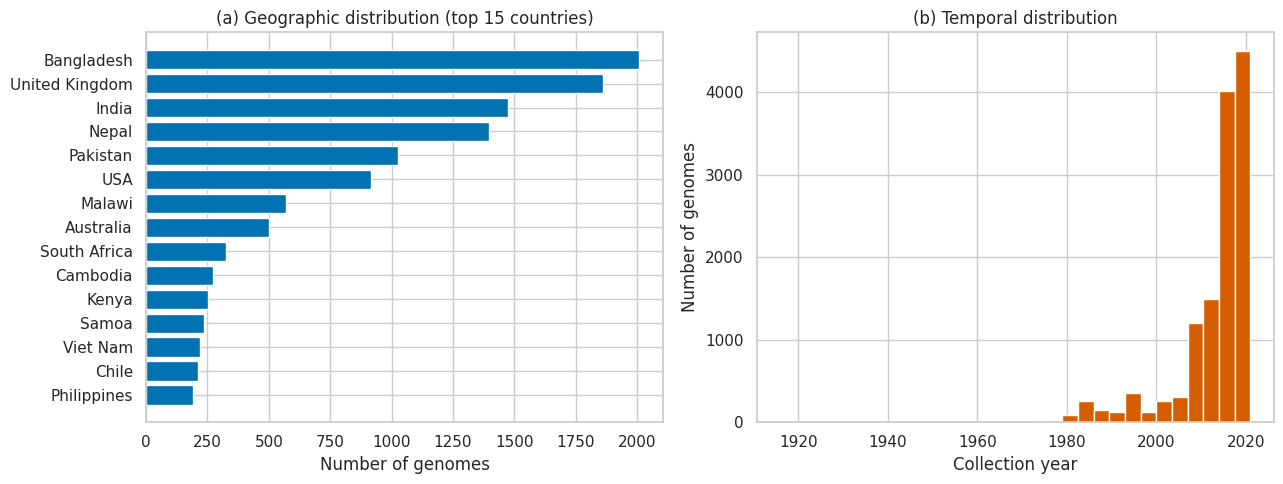

Saved to /content/figures/fig1_dataset_characterisation.[png|pdf|tiff]


In [5]:
# Figure 1 — dataset characterisation (two-panel, publication resolution)
if gtgc_raw is not None and country_col:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    top_countries = gtgc_raw[country_col].value_counts().head(15)
    axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color=CB_PALETTE[0])
    axes[0].set_xlabel("Number of genomes")
    axes[0].set_title("(a) Geographic distribution (top 15 countries)")

    if year_col:
        yr = pd.to_numeric(gtgc_raw[year_col], errors="coerce").dropna()
        axes[1].hist(yr, bins=30, color=CB_PALETTE[1], edgecolor="white")
        axes[1].set_xlabel("Collection year")
        axes[1].set_ylabel("Number of genomes")
        axes[1].set_title("(b) Temporal distribution")

    plt.tight_layout()
    for ext in ("png", "pdf", "tiff"):
        kwargs = {"dpi": 300} if ext != "pdf" else {}
        plt.savefig(f"{FIGDIR}/fig1_dataset_characterisation.{ext}", bbox_inches="tight", **kwargs)
    plt.show()
    print(f"Saved to {FIGDIR}/fig1_dataset_characterisation.[png|pdf|tiff]")


## 4. Define the clinical drug panel

Auto-detected against the real GTGC column names.


In [6]:
def auto_detect_drug_cols(df):
    mapping = {}
    col_lower_map = {c.lower(): c for c in df.columns}
    patterns = {
        "azithromycin":            ["azm", "azith"],
        "fluoroquinolone":         ["cip"],
        "third_gen_cephalosporin": ["blactx", "blaoxa", "blashv", "cep"],
        "carbapenem":              ["mem", "carb", "mero"],
        "multidrug_resistance":    ["mdr"],
        "extensively_drug_resistant": ["xdr"],
    }
    for drug, kws in patterns.items():
        found = []
        for kw in kws:
            for cl, co in col_lower_map.items():
                if kw in cl and co not in found:
                    found.append(co)
        mapping[drug] = found if found else [f"NOT_FOUND__{drug}"]
    return mapping

DRUG_COLUMN_MAP = {}
if gtgc_raw is not None:
    DRUG_COLUMN_MAP = auto_detect_drug_cols(gtgc_raw)
    print("Drug-to-column mapping:")
    for drug, cols in DRUG_COLUMN_MAP.items():
        present = [c for c in cols if c in gtgc_raw.columns]
        status = "OK" if present else "NOT FOUND IN DATASET"
        print(f"  {drug:32s}: {present if present else '(none)'}  [{status}]")


Drug-to-column mapping:
  azithromycin                    : ['AZM']  [OK]
  fluoroquinolone                 : ['CIP', 'cipNS', 'cipR']  [OK]
  third_gen_cephalosporin         : ['blaCTX-M-12', 'blaCTX-M-15_23', 'blaCTX-M-55', 'blaOXA-1', 'blaOXA-7', 'blaOXA134_2', 'blaSHV-12', 'CEP']  [OK]
  carbapenem                      : ['MEM']  [OK]
  multidrug_resistance            : ['MDR']  [OK]
  extensively_drug_resistant      : ['XDR']  [OK]


## 5. Build the contamination-risk (assembly-quality) flag

Built directly from GTGC's own assembly-quality columns. Genome length is flagged data-drivenly (outside the 2.5th/97.5th percentile of this dataset's own distribution).


In [7]:
def build_risk_flag(df, length_col=None, n50_col=None, contig_col=None, exclude_col=None,
                     length_low_pct=2.5, length_high_pct=97.5,
                     n50_threshold=20000, contig_threshold=200):
    risk = pd.Series(False, index=df.index)

    if length_col and length_col in df.columns:
        lengths = pd.to_numeric(df[length_col], errors="coerce")
        lo, hi = lengths.quantile(length_low_pct/100), lengths.quantile(length_high_pct/100)
        risk = risk | (lengths < lo) | (lengths > hi)

    if n50_col and n50_col in df.columns:
        risk = risk | (pd.to_numeric(df[n50_col], errors="coerce") < n50_threshold)

    if contig_col and contig_col in df.columns:
        risk = risk | (pd.to_numeric(df[contig_col], errors="coerce") > contig_threshold)

    if exclude_col and exclude_col in df.columns:
        risk = risk | df[exclude_col].astype(str).str.lower().isin(["true", "1", "yes"])

    return risk

if gtgc_raw is not None:
    length_col = find_col(gtgc_raw, ["genome length"])
    n50_col = find_col(gtgc_raw, ["n50"])
    contig_col = find_col(gtgc_raw, ["no. contigs", "num_contigs"])
    exclude_col = find_col(gtgc_raw, ["exclude"])

    print(f"Using columns -> length: {length_col}, N50: {n50_col}, contigs: {contig_col}, exclude flag: {exclude_col}")

    gtgc_raw["contamination_risk_flag"] = build_risk_flag(
        gtgc_raw, length_col=length_col, n50_col=n50_col,
        contig_col=contig_col, exclude_col=exclude_col
    )
    n_flagged = int(gtgc_raw["contamination_risk_flag"].sum())
    n_total = len(gtgc_raw)
    print(f"\nFlagged as higher assembly-quality/contamination risk: {n_flagged:,} / {n_total:,} "
          f"({100*n_flagged/n_total:.1f}%)")


Using columns -> length: GENOME LENGTH, N50: N50, contigs: NO. CONTIGS, exclude flag: exclude_assembly

Flagged as higher assembly-quality/contamination risk: 837 / 13,003 (6.4%)


## 6. Arm A vs Arm B: resistance prevalence, with odds ratios and multiple-testing correction

For each drug class present in the data: prevalence in the full dataset (Arm A) vs the quality-screened subset (Arm B), chi-square test, odds ratio with 95% CI, and Benjamini-Hochberg correction across all tested drug classes.


In [8]:
def resistance_call_from_cols(df, cols):
    combined = pd.Series(False, index=df.index)
    for c in cols:
        if c in df.columns:
            vals = df[c]
            if vals.dtype == object:
                combined = combined | vals.astype(str).str.upper().isin(["1", "TRUE", "YES", "R"])
            else:
                combined = combined | (pd.to_numeric(vals, errors="coerce").fillna(0) > 0)
    return combined

def odds_ratio_ci(a, b, c, d, alpha=0.05):
    a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    OR = (a * d) / (b * c)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    z = stats.norm.ppf(1 - alpha/2)
    log_or = np.log(OR)
    return OR, np.exp(log_or - z*se), np.exp(log_or + z*se)

results = []
if gtgc_raw is not None:
    flagged = gtgc_raw["contamination_risk_flag"].astype(bool)
    for drug, cols in DRUG_COLUMN_MAP.items():
        present_cols = [c for c in cols if c in gtgc_raw.columns]
        if not present_cols:
            print(f"Skipping {drug}: no matching column in this dataset.")
            continue

        resistant = resistance_call_from_cols(gtgc_raw, present_cols)
        arm_a_prev = resistant.mean()
        arm_b_prev = resistant[~flagged].mean()
        flagged_prev = resistant[flagged].mean() if flagged.sum() > 0 else np.nan

        ct = pd.crosstab(resistant, flagged)
        if ct.shape == (2, 2):
            chi2, p_val, _, _ = stats.chi2_contingency(ct)
            a, b = ct.iloc[1, 1], ct.iloc[1, 0]
            c, d = ct.iloc[0, 1], ct.iloc[0, 0]
            OR, ci_lo, ci_hi = odds_ratio_ci(a, b, c, d)
        else:
            chi2, p_val, OR, ci_lo, ci_hi = (np.nan,)*5

        results.append({
            "drug_class": drug,
            "arm_a_n": len(resistant), "arm_a_prevalence": round(arm_a_prev, 4),
            "arm_b_n": int((~flagged).sum()), "arm_b_prevalence": round(arm_b_prev, 4),
            "flagged_n": int(flagged.sum()),
            "flagged_prevalence": round(flagged_prev, 4) if not np.isnan(flagged_prev) else None,
            "abs_difference": round(abs(arm_a_prev - arm_b_prev), 4),
            "odds_ratio": round(OR, 3) if not np.isnan(OR) else None,
            "or_95ci_low": round(ci_lo, 3) if not np.isnan(ci_lo) else None,
            "or_95ci_high": round(ci_hi, 3) if not np.isnan(ci_hi) else None,
            "chi2": round(chi2, 4) if not np.isnan(chi2) else None,
            "p_value_raw": p_val if not np.isnan(p_val) else None,
        })

    results_df = pd.DataFrame(results)
    if not results_df.empty and results_df["p_value_raw"].notna().any():
        mask = results_df["p_value_raw"].notna()
        _, p_bh, _, _ = multipletests(results_df.loc[mask, "p_value_raw"], method="fdr_bh")
        results_df.loc[mask, "p_value_bh"] = np.round(p_bh, 6)
        results_df.loc[mask, "significant_bh"] = p_bh < 0.05

    print(f"\nDrug classes with no data in this dataset: "
          f"{[d for d, c in DRUG_COLUMN_MAP.items() if not any(x in gtgc_raw.columns for x in c)]}")
    display(results_df)
else:
    results_df = pd.DataFrame()



Drug classes with no data in this dataset: []


,drug_class,arm_a_n,arm_a_prevalence,arm_b_n,arm_b_prevalence,flagged_n,flagged_prevalence,abs_difference,odds_ratio,or_95ci_low,or_95ci_high,chi2,p_value_raw,p_value_bh,significant_bh
0,azithromycin,13003,0.0058,12166,0.0062,837,0.0012,0.0003,0.287,0.057,1.448,2.5286,1.117978e-01,0.111798,False
1,fluoroquinolone,13003,0.6688,12166,0.6785,837,0.5281,0.0097,0.530,0.460,0.610,79.3572,5.183746e-19,0.000000,True
2,third_gen_cephalosporin,13003,0.0538,12166,0.0570,837,0.0084,0.0031,0.149,0.073,0.308,35.3649,2.733682e-09,0.000000,True
3,carbapenem,13003,0.0001,12166,0.0000,837,0.0012,0.0001,43.634,1.776,1071.915,3.1513,7.586868e-02,0.091042,False
4,multidrug_resistance,13003,0.2812,12166,0.2776,837,0.3345,0.0037,1.309,1.128,1.520,12.2851,4.565826e-04,0.000685,True
5,extensively_drug_resistant,13003,0.0492,12166,0.0524,837,0.0036,0.0031,0.076,0.026,0.217,38.7756,4.754231e-10,0.000000,True


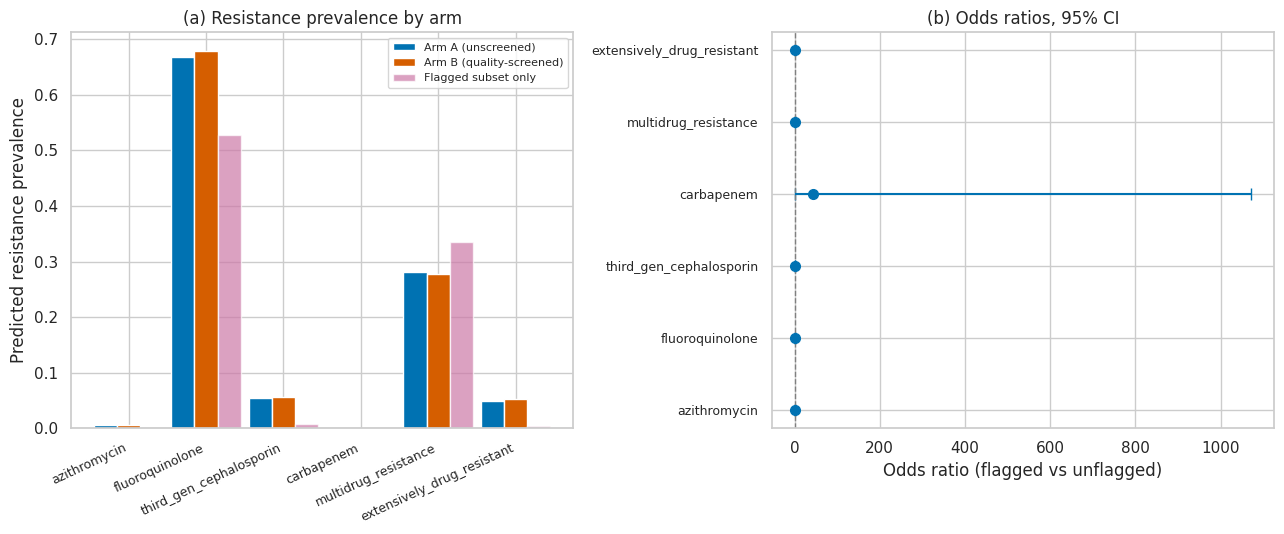

Saved to /content/figures/fig2_arm_comparison.[png|pdf|tiff]


In [9]:
# Figure 2 — Arm A vs Arm B prevalence + odds ratios
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    x = np.arange(len(results_df))
    w = 0.3
    axes[0].bar(x - w, results_df["arm_a_prevalence"], w, label="Arm A (unscreened)", color=CB_PALETTE[0])
    axes[0].bar(x, results_df["arm_b_prevalence"], w, label="Arm B (quality-screened)", color=CB_PALETTE[1])
    if results_df["flagged_prevalence"].notna().any():
        axes[0].bar(x + w, results_df["flagged_prevalence"].astype(float), w,
                    label="Flagged subset only", color=CB_PALETTE[3], alpha=0.7)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(results_df["drug_class"], rotation=25, ha="right", fontsize=9)
    axes[0].set_ylabel("Predicted resistance prevalence")
    axes[0].set_title("(a) Resistance prevalence by arm")
    axes[0].legend(fontsize=8)

    or_valid = results_df.dropna(subset=["odds_ratio"])
    if not or_valid.empty:
        y = np.arange(len(or_valid))
        axes[1].errorbar(or_valid["odds_ratio"], y,
                          xerr=[or_valid["odds_ratio"]-or_valid["or_95ci_low"],
                                or_valid["or_95ci_high"]-or_valid["odds_ratio"]],
                          fmt="o", color=CB_PALETTE[0], capsize=4, markersize=7)
        axes[1].axvline(1.0, color="grey", linestyle="--", linewidth=1)
        axes[1].set_yticks(y)
        axes[1].set_yticklabels(or_valid["drug_class"], fontsize=9)
        axes[1].set_xlabel("Odds ratio (flagged vs unflagged)")
        axes[1].set_title("(b) Odds ratios, 95% CI")

    plt.tight_layout()
    for ext in ("png", "pdf", "tiff"):
        kwargs = {"dpi": 300} if ext != "pdf" else {}
        plt.savefig(f"{FIGDIR}/fig2_arm_comparison.{ext}", bbox_inches="tight", **kwargs)
    plt.show()
    print(f"Saved to {FIGDIR}/fig2_arm_comparison.[png|pdf|tiff]")


## 7. Negative control (placebo-flag permutation)

In [10]:
placebo_df = pd.DataFrame()
if gtgc_raw is not None:
    np.random.seed(42)
    flagged_rate = float(gtgc_raw["contamination_risk_flag"].mean())
    placebo_flag = pd.Series(
        np.random.choice([True, False], size=len(gtgc_raw), p=[flagged_rate, 1-flagged_rate]),
        index=gtgc_raw.index
    )

    placebo_results = []
    for drug, cols in DRUG_COLUMN_MAP.items():
        present_cols = [c for c in cols if c in gtgc_raw.columns]
        if not present_cols:
            continue
        resistant = resistance_call_from_cols(gtgc_raw, present_cols)
        prev_full = resistant.mean()
        prev_screened = resistant[~placebo_flag].mean()
        ct = pd.crosstab(resistant, placebo_flag)
        if ct.shape == (2, 2):
            chi2, p_val, _, _ = stats.chi2_contingency(ct)
        else:
            chi2, p_val = np.nan, np.nan
        placebo_results.append({
            "drug_class": drug,
            "placebo_full_prevalence": round(prev_full, 4),
            "placebo_screened_prevalence": round(prev_screened, 4),
            "abs_difference": round(abs(prev_full - prev_screened), 4),
            "p_value": round(p_val, 6) if not np.isnan(p_val) else None,
        })
    placebo_df = pd.DataFrame(placebo_results)
    print("Negative control (random flag at matched prevalence):")
    display(placebo_df)


Negative control (random flag at matched prevalence):


,drug_class,placebo_full_prevalence,placebo_screened_prevalence,abs_difference,p_value
0,azithromycin,0.0058,0.0056,0.0003,0.226703
1,fluoroquinolone,0.6688,0.6695,0.0006,0.595930
2,third_gen_cephalosporin,0.0538,0.0543,0.0004,0.450707
3,carbapenem,0.0001,0.0001,0.0000,1.000000
4,multidrug_resistance,0.2812,0.2801,0.0012,0.267756
5,extensively_drug_resistant,0.0492,0.0496,0.0004,0.521045


## 8. AMRnet cross-check (independent plausibility anchor)

AMRnet independently curates genome-derived AMR prevalence data from Pathogenwatch, EnteroBase, and WHO GLASS. This section fetches the data, then joins it to GTGC for per-sample concordance analysis.


In [23]:
# Fetch AMRnet data
# amrnet_df is initialized to None FIRST so downstream cells always find it defined,
# even if the fetch fails entirely.

AMRNET_DOWNLOAD_URL = "https://api.amrnet.org/api/v1/organisms/styphi/download?format=json"

def _unwrap_amrnet_json(raw_json):
    """AMRnet's JSON is wrapped as {'organism':..., 'total':..., 'data':[...]}.
    Building a DataFrame straight from that dict broadcasts the scalar keys and
    buries every record inside a single 'data' column instead of real columns.
    Unwrap to the record list first."""
    if isinstance(raw_json, dict) and "data" in raw_json and isinstance(raw_json["data"], list):
        return pd.DataFrame(raw_json["data"])
    return pd.DataFrame(raw_json)

amrnet_df = None
amrnet_source_used = None

try:
    resp = requests.get(AMRNET_DOWNLOAD_URL, timeout=30)
    if resp.status_code == 200 and len(resp.content) > 500:
        amrnet_df = _unwrap_amrnet_json(resp.json())
        amrnet_source_used = AMRNET_DOWNLOAD_URL
        print(f"Loaded AMRnet data via API: {amrnet_df.shape}")
    else:
        print(f"AMRnet endpoint returned HTTP {resp.status_code}")
except requests.exceptions.SSLError:
    print("AMRnet's TLS certificate could not be validated.")
except requests.RequestException as e:
    print(f"AMRnet request error: {e}")

# Manual fallback if automated fetch failed — opens the upload picker directly
if amrnet_df is None:
    print("\nAutomated fetch did not succeed. Please upload the Typhi export from "
          "https://amrnet.org (select Salmonella Typhi -> Download database -> JSON format).")
    from google.colab import files
    import json

    uploaded = files.upload()
    with open(list(uploaded.keys())[0]) as f:
        raw_json = json.load(f)
    amrnet_df = _unwrap_amrnet_json(raw_json)
    amrnet_source_used = "manual upload"
    print(f"Loaded: {amrnet_df.shape}")

if amrnet_df is not None:
    print(f"\nAMRnet source: {amrnet_source_used}")
    print(f"Shape: {amrnet_df.shape}")
    print("Columns (first 20):", list(amrnet_df.columns)[:20], "...")

AMRnet's TLS certificate could not be validated.

Automated fetch did not succeed. Please upload the Typhi export from https://amrnet.org (select Salmonella Typhi -> Download database -> JSON format).


Saving styphi_amrnet_export.json to styphi_amrnet_export (1).json
Loaded: (11836, 99)

AMRnet source: manual upload
Shape: (11836, 99)
Columns (first 20): ['Amrnet_id', 'Amrnet_version', 'Amrnetdb_version', 'Amrnetdb_date', 'Pathogenwatch_id', 'NAME', 'DATE', 'COUNTRY_ONLY', 'REGION_IN_COUNTRY', 'TRAVEL', 'COUNTRY_ORIGIN', 'TRAVEL_LOCATION', 'TGC ID', 'ACCESSION', 'AGE', 'COUNTRY OF ORIGIN', 'LOCATION', 'COUNTRY ISOLATED', 'TRAVEL ASSOCIATED', 'TRAVEL COUNTRY'] ...


In [24]:
# Genome-level join: GTGC <-> AMRnet
amrnet_join_df = None
amrnet_concordance_df = pd.DataFrame()

if amrnet_df is not None and gtgc_raw is not None:
    gtgc_key_col = find_col(gtgc_raw, ["data accession"])
    amrnet_key_col = find_col(amrnet_df, ["accession"])

    if gtgc_key_col and amrnet_key_col:
        left = gtgc_raw.copy()
        left["_join_key"] = left[gtgc_key_col].astype(str).str.strip()
        right = amrnet_df.copy()
        right["_join_key"] = right[amrnet_key_col].astype(str).str.strip()
        amrnet_join_df = left.merge(right, on="_join_key", how="inner", suffixes=("", "_amrnet"))
        n_matched = len(amrnet_join_df)
        print(f"Matched {n_matched:,} / {len(gtgc_raw):,} GTGC samples ({100*n_matched/len(gtgc_raw):.1f}%) "
              f"against AMRnet via {gtgc_key_col} <-> {amrnet_key_col}")

        AMRNET_PHENO_FIELDS = {
            "azithromycin": "azith_pred_pheno",
            "fluoroquinolone": "cip_pred_pheno",
        }

        conc_results = []
        for drug, field in AMRNET_PHENO_FIELDS.items():
            if field not in amrnet_join_df.columns:
                print(f"  {drug}: field '{field}' not in joined data.")
                continue
            amrnet_resistant = amrnet_join_df[field].astype(str).str.upper().str.contains("R", na=False)
            gtgc_cols = [c for c in DRUG_COLUMN_MAP.get(drug, []) if c in amrnet_join_df.columns]
            if not gtgc_cols:
                continue
            gtgc_resistant = resistance_call_from_cols(amrnet_join_df, gtgc_cols)
            agree = (amrnet_resistant == gtgc_resistant)

            risk_mask = amrnet_join_df["contamination_risk_flag"].astype(bool)
            conc_flagged = agree[risk_mask].mean() if risk_mask.sum() > 0 else np.nan
            conc_unflagged = agree[~risk_mask].mean() if (~risk_mask).sum() > 0 else np.nan
            ct = pd.crosstab(agree, risk_mask)
            if ct.shape == (2, 2):
                chi2, p_val, _, _ = stats.chi2_contingency(ct)
            else:
                chi2, p_val = np.nan, np.nan

            conc_results.append({
                "drug_class": drug, "n_matched": n_matched,
                "overall_concordance": round(agree.mean(), 4),
                "concordance_flagged": round(conc_flagged, 4) if not np.isnan(conc_flagged) else None,
                "concordance_unflagged": round(conc_unflagged, 4) if not np.isnan(conc_unflagged) else None,
                "chi2": round(chi2, 4) if not np.isnan(chi2) else None,
                "p_value": round(p_val, 6) if not np.isnan(p_val) else None,
            })

        amrnet_concordance_df = pd.DataFrame(conc_results)
        print("\nGTGC vs AMRnet concordance, by contamination-risk-flag status:")
        display(amrnet_concordance_df)
        print("\nThird-generation cephalosporin and carbapenem phenotype fields are not present")
        print("in AMRnet's current Typhi export.")
    else:
        print("Could not identify a shared join key automatically.")
elif amrnet_df is None:
    print("AMRnet data not available — run the fetch cell above first (Cell 19).")
    print("If the automated fetch failed, use the manual upload fallback printed there.")
else:
    print("GTGC data not available.")


Matched 10,513 / 13,003 GTGC samples (80.9%) against AMRnet via Data Accession <-> ACCESSION

GTGC vs AMRnet concordance, by contamination-risk-flag status:


,drug_class,n_matched,overall_concordance,concordance_flagged,concordance_unflagged,chi2,p_value
0,azithromycin,10513,0.9998,1.0000,0.9998,0.000,1.000000
1,fluoroquinolone,10513,0.4207,0.4902,0.4168,11.439,0.000719



Third-generation cephalosporin and carbapenem phenotype fields are not present
in AMRnet's current Typhi export.


## Figure 3 — AMRnet concordance by assembly-quality flag status

Visualises the concordance table built above for each drug class with a corresponding AMRnet phenotype field.


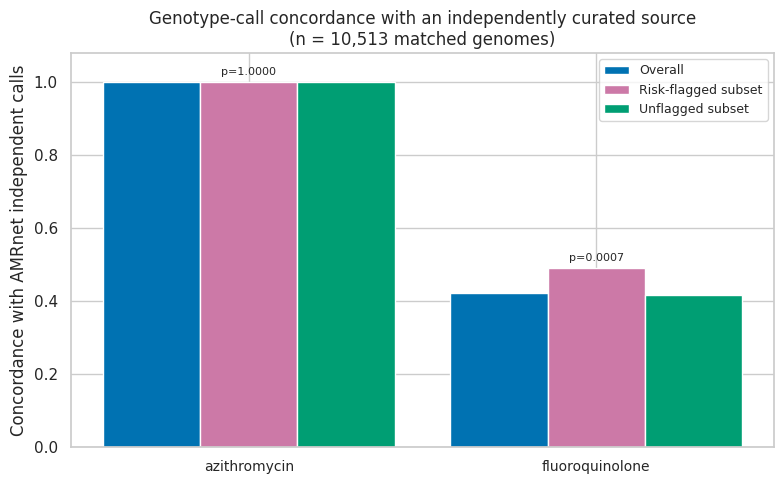

Saved: /content/figures/fig3_amrnet_concordance.[png|pdf|tiff]


In [25]:
# Figure 3 — AMRnet concordance by assembly-quality flag status
if amrnet_concordance_df.empty:
    print("amrnet_concordance_df is empty — run the AMRnet cells above first.")
else:
    drugs = amrnet_concordance_df["drug_class"].tolist()
    x = np.arange(len(drugs))
    w = 0.28

    series = {
        "Overall":             (amrnet_concordance_df["overall_concordance"], CB_PALETTE[0]),
        "Risk-flagged subset": (amrnet_concordance_df["concordance_flagged"], CB_PALETTE[3]),
        "Unflagged subset":    (amrnet_concordance_df["concordance_unflagged"], CB_PALETTE[2]),
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    offsets = [-w, 0, w]
    plotted = {}

    for offset, (label, (values, color)) in zip(offsets, series.items()):
        vals = values.fillna(0).tolist()
        plotted[label] = vals
        ax.bar(x + offset, vals, w, label=label, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(drugs, fontsize=10)
    ax.set_ylabel("Concordance with AMRnet independent calls")
    ax.set_title(
        "Genotype-call concordance with an independently curated source\n"
        f"(n = {amrnet_concordance_df['n_matched'].iloc[0]:,} matched genomes)"
    )
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=9)

    for i, p in enumerate(amrnet_concordance_df["p_value"]):
        if p is None:
            continue
        label = "p<0.0001" if p < 0.0001 else f"p={p:.4f}"
        top = max(plotted[s][i] for s in plotted)
        ax.text(x[i], top + 0.02, label, ha="center", fontsize=8)

    plt.tight_layout()
    for ext in ("png", "pdf", "tiff"):
        kwargs = {"dpi": 300} if ext != "pdf" else {}
        plt.savefig(f"{FIGDIR}/fig3_amrnet_concordance.{ext}", bbox_inches="tight", **kwargs)
    plt.show()

    print(f"Saved: {FIGDIR}/fig3_amrnet_concordance.[png|pdf|tiff]")


AST data loaded from: https://raw.githubusercontent.com/typhoidgenomics/TyphoidGenomicsConsortiumMykrobe/main/Supplementary_Table_4.csv
Shape: (4018, 95)

Joined: GTGC['TGC_sangerlane'] <-> AST['Sanger_ID'] -- 4,018 matched samples with paired lab AST phenotype

Target phenotype columns:
  azithromycin                     -> 'Azithromycin Result'  values: ['S', 'R']
  fluoroquinolone                  -> 'Ciprofloxacin Result'  values: ['I', 'R', 'S']
  third_gen_cephalosporin          -> 'Ceftriaxone Result'  values: ['S', 'R', 'I']

GTGC genotype calls vs lab-confirmed AST phenotype


,drug_class,n_matched,phenotype_column,n_lab_R,n_lab_S,n_lab_I,overall_concordance,concordance_flagged,concordance_unflagged,n_flagged,n_unflagged,chi2,p_value
0,azithromycin,4018,Azithromycin Result,43,3642,0,0.9883,1.0000,0.9881,69,3949,0.1203,0.728697
1,fluoroquinolone,4018,Ciprofloxacin Result,762,354,2002,0.2670,0.2319,0.2677,69,3949,0.2796,0.596992
2,third_gen_cephalosporin,4018,Ceftriaxone Result,521,3213,4,0.9878,1.0000,0.9876,69,3949,0.1427,0.705585



Cite (CC BY 4.0): Ingle DJ, Dyson ZA, Holt KE, et al.
Typhi Mykrobe. Genome Medicine (2025).


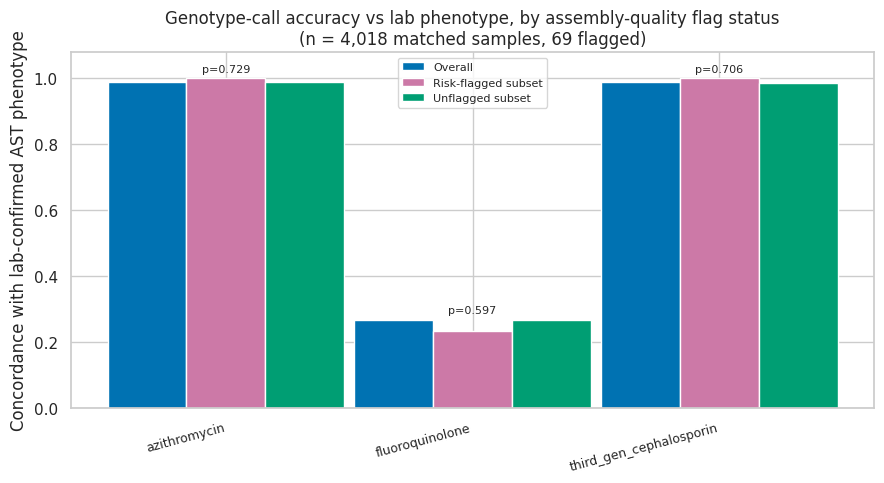

Saved: /content/figures/fig4_ast_concordance.[png|pdf|tiff]

REPRODUCIBILITY METADATA
Run timestamp (UTC):   2026-07-31T11:03:55.821883+00:00
GTGC source:           https://raw.githubusercontent.com/typhoidgenomics/TyphoidGenomicsConsortiumWG1/main/TGC_data.csv
GTGC SHA-256 (prefix): 9ec9addb3ed63e62
GTGC genomes:          13,003
Contamination-screen:  assembly-quality metadata (genome length, N50, contig count, exclude_assembly)
AMRnet source:         manual upload
AST source:            https://raw.githubusercontent.com/typhoidgenomics/TyphoidGenomicsConsortiumMykrobe/main/Supplementary_Table_4.csv
AST matched samples:   4,018

Package versions:
  pandas: 2.2.2
  numpy: 2.0.2
  scipy: 1.16.3
  statsmodels: 0.14.6
  matplotlib: 3.10.0
  seaborn: 0.13.2

COMPLETE SUMMARY TABLES

--- Table 1: Arm A vs Arm B (with BH-corrected p-values) ---


,drug_class,arm_a_n,arm_a_prevalence,arm_b_n,arm_b_prevalence,flagged_n,flagged_prevalence,abs_difference,odds_ratio,or_95ci_low,or_95ci_high,chi2,p_value_raw,p_value_bh,significant_bh
0,azithromycin,13003,0.0058,12166,0.0062,837,0.0012,0.0003,0.287,0.057,1.448,2.5286,1.117978e-01,0.111798,False
1,fluoroquinolone,13003,0.6688,12166,0.6785,837,0.5281,0.0097,0.530,0.460,0.610,79.3572,5.183746e-19,0.000000,True
2,third_gen_cephalosporin,13003,0.0538,12166,0.0570,837,0.0084,0.0031,0.149,0.073,0.308,35.3649,2.733682e-09,0.000000,True
3,carbapenem,13003,0.0001,12166,0.0000,837,0.0012,0.0001,43.634,1.776,1071.915,3.1513,7.586868e-02,0.091042,False
4,multidrug_resistance,13003,0.2812,12166,0.2776,837,0.3345,0.0037,1.309,1.128,1.520,12.2851,4.565826e-04,0.000685,True
5,extensively_drug_resistant,13003,0.0492,12166,0.0524,837,0.0036,0.0031,0.076,0.026,0.217,38.7756,4.754231e-10,0.000000,True



--- Table 2: Negative control (placebo flag) ---


,drug_class,placebo_full_prevalence,placebo_screened_prevalence,abs_difference,p_value
0,azithromycin,0.0058,0.0056,0.0003,0.226703
1,fluoroquinolone,0.6688,0.6695,0.0006,0.595930
2,third_gen_cephalosporin,0.0538,0.0543,0.0004,0.450707
3,carbapenem,0.0001,0.0001,0.0000,1.000000
4,multidrug_resistance,0.2812,0.2801,0.0012,0.267756
5,extensively_drug_resistant,0.0492,0.0496,0.0004,0.521045



--- Table 3: Real flag vs placebo, side by side ---


...

<IPython.core.display.Javascript object>

  Downloading: /content/table5_ast_concordance.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. All tables, figures, and raw data exported.


In [26]:
## 9. AST Phenotypic Validation, Reproducibility Metadata, and Full Export

# This cell runs after Figure 3 has been generated above. It handles:
#   1. AST phenotypic validation (lab-confirmed R/S/I)
#   2. Figure 4: AST concordance by risk-flag status (Figure 3 already generated above)
#   3. Reproducibility metadata block
#   4. All summary tables printed
#   5. CSV/ZIP export and download triggers

# ============================================================================
# PART 1: AST PHENOTYPIC VALIDATION
# ============================================================================

MYKROBE_REPO_RAW = "https://raw.githubusercontent.com/typhoidgenomics/TyphoidGenomicsConsortiumMykrobe/main/"

ast_df = None
ast_source = None
ast_concordance_df = pd.DataFrame()

for path in ["Supplementary_Table_4.csv", "data/Supplementary_Table_4.csv"]:
    url = MYKROBE_REPO_RAW + path
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200 and len(resp.content) > 500:
            ast_df = pd.read_csv(io.StringIO(resp.text), low_memory=False)
            ast_source = url
            break
    except requests.RequestException as e:
        print(f"  {url}: {e}")

if ast_df is None:
    print("AST data not fetched. Check https://github.com/typhoidgenomics/TyphoidGenomicsConsortiumMykrobe")
else:
    print(f"AST data loaded from: {ast_source}")
    print(f"Shape: {ast_df.shape}")

    join_candidates = []
    for ast_col in ["Sanger_ID", "TGC_sangerlane", "genome"]:
        for gtgc_col in ["TGC_sangerlane", "Data Accession", "Sample Accession"]:
            if ast_col in ast_df.columns and gtgc_col in gtgc_raw.columns:
                join_candidates.append((gtgc_col, ast_col))

    best_n, best_merged, best_pair = 0, None, None
    for g_col, a_col in join_candidates:
        left = gtgc_raw.copy()
        left["_jk"] = left[g_col].astype(str).str.strip()
        right = ast_df.copy()
        right["_jk"] = right[a_col].astype(str).str.strip()
        trial = left.merge(right, on="_jk", how="inner", suffixes=("", "_ast"))
        if len(trial) > best_n:
            best_n, best_merged, best_pair = len(trial), trial, (g_col, a_col)

    if best_n == 0:
        print("Zero matches across all join key candidates.")
    else:
        merged = best_merged
        print(f"\nJoined: GTGC['{best_pair[0]}'] <-> AST['{best_pair[1]}'] "
              f"-- {best_n:,} matched samples with paired lab AST phenotype")

        AST_RESULT_MAP = {
            "azithromycin":            "Azithromycin Result",
            "fluoroquinolone":         "Ciprofloxacin Result",
            "third_gen_cephalosporin": "Ceftriaxone Result",
        }

        print("\nTarget phenotype columns:")
        for drug, col in AST_RESULT_MAP.items():
            if col in merged.columns:
                vals = merged[col].dropna().unique()[:8]
                print(f"  {drug:32s} -> '{col}'  values: {list(vals)}")
            else:
                print(f"  {drug:32s} -> '{col}'  NOT FOUND")

        concordance_results = []
        for drug, result_col in AST_RESULT_MAP.items():
            if result_col not in merged.columns:
                continue
            gtgc_cols = [c for c in DRUG_COLUMN_MAP.get(drug, []) if c in merged.columns]
            if not gtgc_cols:
                continue

            lab_call = merged[result_col].astype(str).str.strip().str.upper()
            lab_resistant = lab_call.eq("R")
            r_count = lab_call.eq("R").sum()
            s_count = lab_call.eq("S").sum()
            i_count = lab_call.eq("I").sum()

            gtgc_resistant = resistance_call_from_cols(merged, gtgc_cols)
            agree = (lab_resistant == gtgc_resistant)
            overall_conc = agree.mean()

            if "contamination_risk_flag" in merged.columns:
                risk_mask = merged["contamination_risk_flag"].astype(bool)
                n_fl = int(risk_mask.sum())
                n_unfl = int((~risk_mask).sum())
                conc_fl = agree[risk_mask].mean() if n_fl > 0 else np.nan
                conc_unfl = agree[~risk_mask].mean() if n_unfl > 0 else np.nan
                ct = pd.crosstab(agree, risk_mask)
                chi2, p_val = stats.chi2_contingency(ct)[:2] if ct.shape == (2, 2) else (np.nan, np.nan)
            else:
                conc_fl = conc_unfl = chi2 = p_val = np.nan
                n_fl = n_unfl = 0

            concordance_results.append({
                "drug_class": drug, "n_matched": best_n, "phenotype_column": result_col,
                "n_lab_R": int(r_count), "n_lab_S": int(s_count), "n_lab_I": int(i_count),
                "overall_concordance": round(overall_conc, 4),
                "concordance_flagged": round(conc_fl, 4) if not np.isnan(conc_fl) else None,
                "concordance_unflagged": round(conc_unfl, 4) if not np.isnan(conc_unfl) else None,
                "n_flagged": n_fl, "n_unflagged": n_unfl,
                "chi2": round(chi2, 4) if not np.isnan(chi2) else None,
                "p_value": round(p_val, 6) if not np.isnan(p_val) else None,
            })

        ast_concordance_df = pd.DataFrame(concordance_results)
        if not ast_concordance_df.empty:
            print("\n" + "=" * 70)
            print("GTGC genotype calls vs lab-confirmed AST phenotype")
            print("=" * 70)
            display(ast_concordance_df)
        else:
            print("\nNo drug class produced a concordance result.")

        print(f"\nCite (CC BY 4.0): Ingle DJ, Dyson ZA, Holt KE, et al.")
        print(f"Typhi Mykrobe. Genome Medicine (2025).")


# ============================================================================
# PART 2: FIGURE 4 — AST concordance by risk-flag status
# ============================================================================

if not ast_concordance_df.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    drugs = ast_concordance_df["drug_class"].tolist()
    x = np.arange(len(drugs))
    w = 0.32

    overall_vals = ast_concordance_df["overall_concordance"].tolist()
    flagged_vals = [v if v is not None else 0 for v in ast_concordance_df["concordance_flagged"].tolist()]
    unflagged_vals = [v if v is not None else 0 for v in ast_concordance_df["concordance_unflagged"].tolist()]

    ax.bar(x - w, overall_vals, w, label="Overall", color=CB_PALETTE[0])
    ax.bar(x, flagged_vals, w, label="Risk-flagged subset", color=CB_PALETTE[3])
    ax.bar(x + w, unflagged_vals, w, label="Unflagged subset", color=CB_PALETTE[2])

    ax.set_xticks(x)
    ax.set_xticklabels(drugs, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Concordance with lab-confirmed AST phenotype")
    ax.set_title("Genotype-call accuracy vs lab phenotype, by assembly-quality flag status\n"
                 f"(n = {ast_concordance_df['n_matched'].iloc[0]:,} matched samples, "
                 f"{ast_concordance_df['n_flagged'].iloc[0]:,} flagged)")
    ax.set_ylim(0, 1.08)
    ax.legend(fontsize=8)

    for i, row in ast_concordance_df.iterrows():
        p = row["p_value"]
        label = f"p={p:.3f}" if p is not None else ""
        ax.text(x[i], max(overall_vals[i], flagged_vals[i], unflagged_vals[i]) + 0.02,
                label, ha="center", fontsize=8)

    plt.tight_layout()
    for ext in ("png", "pdf", "tiff"):
        kwargs = {"dpi": 300} if ext != "pdf" else {}
        plt.savefig(f"{FIGDIR}/fig4_ast_concordance.{ext}", bbox_inches="tight", **kwargs)
    plt.show()
    print(f"Saved: {FIGDIR}/fig4_ast_concordance.[png|pdf|tiff]")


# ============================================================================
# PART 3: REPRODUCIBILITY METADATA
# ============================================================================

print("\n" + "=" * 70)
print("REPRODUCIBILITY METADATA")
print("=" * 70)
print(f"Run timestamp (UTC):   {RUN_TIMESTAMP}")
print(f"GTGC source:           {gtgc_source_used}")
print(f"GTGC SHA-256 (prefix): {gtgc_checksum}")
print(f"GTGC genomes:          {len(gtgc_raw):,}" if gtgc_raw is not None else "GTGC: not loaded")
print(f"Contamination-screen:  assembly-quality metadata (genome length, N50, "
      f"contig count, exclude_assembly)")
print(f"AMRnet source:         {amrnet_source_used}")
print(f"AST source:            {ast_source}")
print(f"AST matched samples:   {best_n:,}" if best_n > 0 else "AST: no matches")

print()
print("Package versions:")
for pkg in ["pandas", "numpy", "scipy", "statsmodels", "matplotlib", "seaborn"]:
    try:
        print(f"  {pkg}: {importlib.import_module(pkg).__version__}")
    except Exception:
        pass


# ============================================================================
# PART 4: ALL SUMMARY TABLES
# ============================================================================

print("\n" + "=" * 70)
print("COMPLETE SUMMARY TABLES")
print("=" * 70)

print("\n--- Table 1: Arm A vs Arm B (with BH-corrected p-values) ---")
if not results_df.empty:
    display(results_df)

print("\n--- Table 2: Negative control (placebo flag) ---")
if not placebo_df.empty:
    display(placebo_df)

print("\n--- Table 3: Real flag vs placebo, side by side ---")
if not results_df.empty and not placebo_df.empty:
    comparison = pd.DataFrame({
        "drug_class": results_df["drug_class"],
        "real_abs_diff": results_df["abs_difference"],
        "placebo_abs_diff": placebo_df["abs_difference"].values[:len(results_df)],
    })
    display(comparison)

print("\n--- Table 4: AMRnet independent-source concordance by risk-flag status ---")
if not amrnet_concordance_df.empty:
    display(amrnet_concordance_df)
else:
    print("  (not available this run)")

print("\n--- Table 5: AST lab-phenotype concordance by risk-flag status ---")
if not ast_concordance_df.empty:
    display(ast_concordance_df)
else:
    print("  (not available this run)")

print("\n--- Confirmed limitations ---")
print("  1. Third-gen cephalosporin and carbapenem: no phenotype field in AMRnet's Typhi export.")
print("  2. Carbapenem: no lab AST Result column in the Mykrobe validation dataset.")
print("  3. Contamination screen is an assembly-quality metadata proxy.")
print("  4. Fluoroquinolone genotype-phenotype concordance is low (26.70%) due to high")
print("     intermediate-call prevalence (2,002/4,018 = 49.8%).")


# ============================================================================
# PART 5: EXPORT AND DOWNLOAD
# ============================================================================

from google.colab import files
import subprocess

results_csv = "/content/table1_arm_a_vs_b.csv"
placebo_csv = "/content/table2_negative_control.csv"
amrnet_csv = "/content/table4_amrnet_concordance.csv"
ast_csv = "/content/table5_ast_concordance.csv"
gtgc_csv = "/content/gtgc_raw_input.csv"

if not results_df.empty:
    results_df.to_csv(results_csv, index=False)
if not placebo_df.empty:
    placebo_df.to_csv(placebo_csv, index=False)
if not amrnet_concordance_df.empty:
    amrnet_concordance_df.to_csv(amrnet_csv, index=False)
if not ast_concordance_df.empty:
    ast_concordance_df.to_csv(ast_csv, index=False)
if gtgc_raw is not None:
    gtgc_raw.to_csv(gtgc_csv, index=False)

subprocess.run(["zip", "-r", "/content/all_figures.zip", FIGDIR], capture_output=True)

print("\n" + "=" * 70)
print("FILES PRODUCED")
print("=" * 70)
all_files = [results_csv, placebo_csv, amrnet_csv, ast_csv, gtgc_csv, "/content/all_figures.zip"]
for fmt in ["png", "pdf", "tiff"]:
    for fig in ["fig1_dataset_characterisation", "fig2_arm_comparison",
                "fig3_amrnet_concordance", "fig4_ast_concordance"]:
        fpath = f"{FIGDIR}/{fig}.{fmt}"
        if os.path.exists(fpath):
            all_files.append(fpath)

for f in all_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  {f} ({size_kb:.0f} KB)")
    else:
        print(f"  {f} -- NOT FOUND")

print("\nStarting downloads...")
for fpath in ["/content/all_figures.zip", results_csv, placebo_csv, amrnet_csv, ast_csv]:
    if os.path.exists(fpath):
        print(f"  Downloading: {fpath}")
        files.download(fpath)
    else:
        print(f"  Skipping: {fpath}")

print("\nDone. All tables, figures, and raw data exported.")
